# 02 — Feature Engineering

Builds and validates all engineered features. `src/features.py` is the single source of truth — this notebook validates and visualises what it produces.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data import load_all
from src.features import prepare_all, get_feature_cols, TARGET

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

train, test, ext, sample_sub = load_all()

Train: 439,140 rows  |  Test: 188,165 rows  |  External (unique): 76,929 rows


In [2]:
print('Running feature engineering pipeline (combine train+test+external, compute features, split)...')
train_feat, test_feat, ext_feat = prepare_all(train, test, ext)
feature_cols = get_feature_cols(train_feat)
print(f'\nTrain feat: {train_feat.shape}  |  Test feat: {test_feat.shape}  |  Ext feat: {ext_feat.shape}')
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')

Running feature engineering pipeline (combine train+test+external, compute features, split)...



Train feat: (439140, 37)  |  Test feat: (188165, 36)  |  Ext feat: (76929, 37)
Feature columns (32): ['TyreLife', 'Stint', 'LapNumber', 'Position', 'RaceProgress', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'Position_Change', 'PitStop', 'LT_lag1', 'LT_lag2', 'LTD_lag1', 'TL_lag1', 'PitStop_lag1', 'LT_roll3_mean', 'LT_roll3_std', 'LTD_roll3_mean', 'NormTyreLife', 'Deg_per_lap', 'EstTotalLaps', 'LapsRemaining', 'LT_race_compound_mean', 'LT_vs_pace', 'TL_x_Stint', 'RP_x_TL', 'LR_x_TL', 'is_year2023', 'is_pretesting', 'is_real_driver', 'Compound_ord', 'Year']


## 1. Missing value audit after feature engineering

In [3]:
null_counts = train_feat[feature_cols].isnull().sum().sort_values(ascending=False)
null_pct = (null_counts / len(train_feat) * 100).round(2)
null_report = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
print(null_report[null_report['null_count'] > 0])

                null_count  null_pct
LT_lag2              55182     12.57
LT_roll3_std         55182     12.57
LT_roll3_mean        29141      6.64
LTD_lag1             29141      6.64
LT_lag1              29141      6.64
PitStop_lag1         29141      6.64
LTD_roll3_mean       29141      6.64
TL_lag1              29141      6.64


## 2. New feature correlations with target

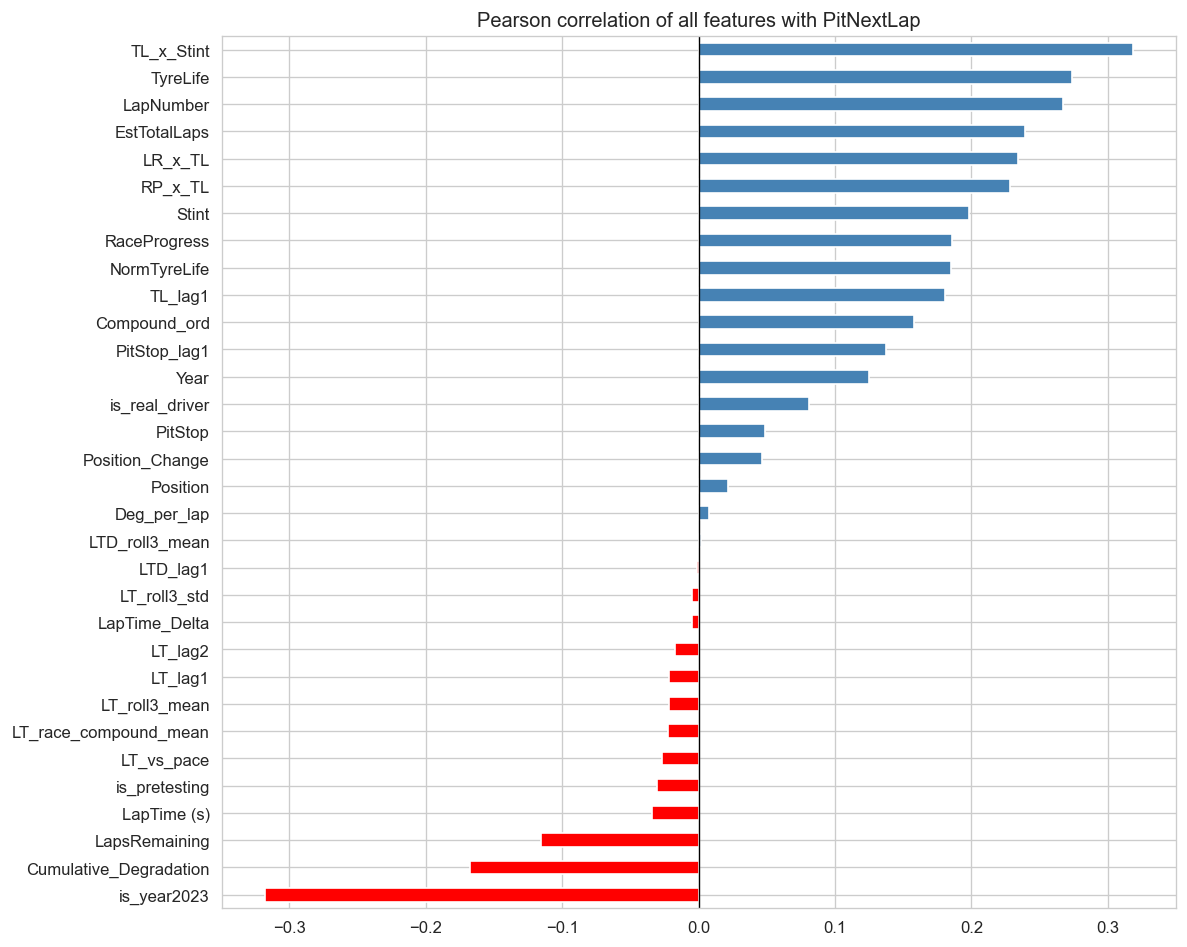

Top positive correlations:
TL_lag1         0.180577
NormTyreLife    0.184965
RaceProgress    0.185477
Stint           0.198193
RP_x_TL         0.228233
LR_x_TL         0.234127
EstTotalLaps    0.238994
LapNumber       0.267057
TyreLife        0.273510
TL_x_Stint      0.318235
Name: PitNextLap, dtype: float64

Top negative correlations:
is_year2023              -0.317967
Cumulative_Degradation   -0.167401
LapsRemaining            -0.115599
LapTime (s)              -0.034096
is_pretesting            -0.030519
LT_vs_pace               -0.026678
LT_race_compound_mean    -0.022083
LT_roll3_mean            -0.021665
LT_lag1                  -0.021338
LT_lag2                  -0.017478
Name: PitNextLap, dtype: float64


In [4]:
num_feat_cols = [c for c in feature_cols if train_feat[c].dtype in [np.float64, np.float32, np.int64, np.int32, np.int8]]
corrs = train_feat[num_feat_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
corrs.plot(kind='barh', ax=ax, color=['red' if c < 0 else 'steelblue' for c in corrs])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson correlation of all features with PitNextLap')
plt.tight_layout()
plt.show()
print('Top positive correlations:')
print(corrs.tail(10))
print('\nTop negative correlations:')
print(corrs.head(10))

## 3. LapsRemaining — key engineered feature

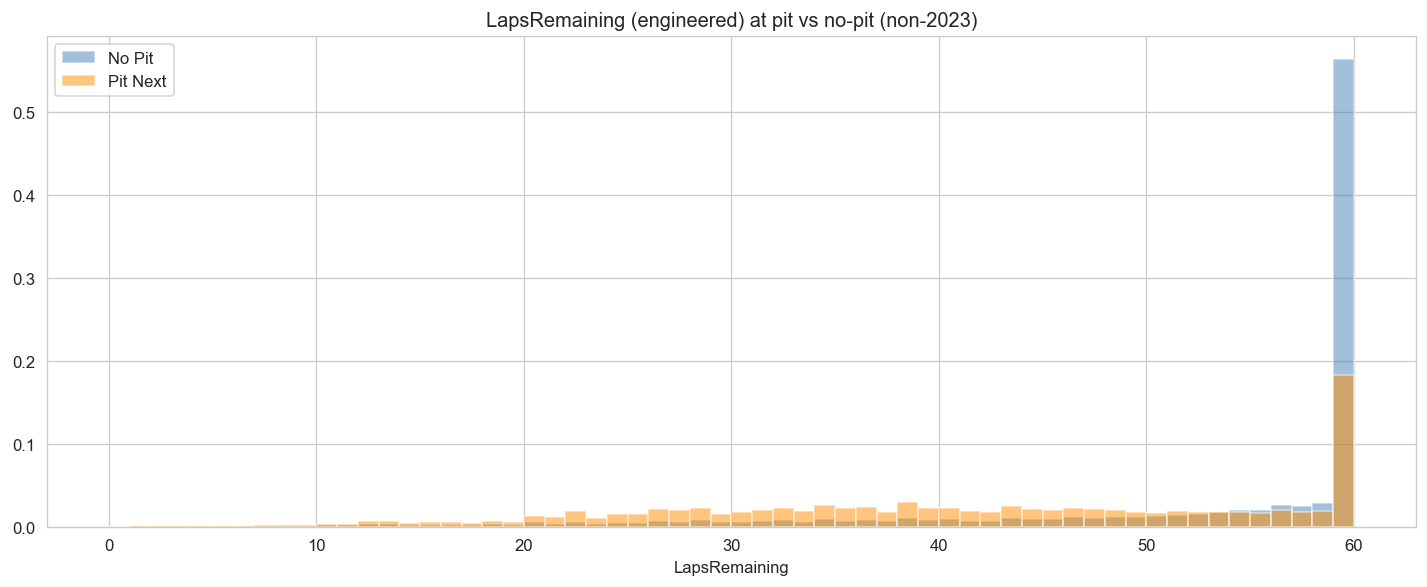

In [5]:
non2023_feat = train_feat[train_feat['Year'] != 2023]

fig, ax = plt.subplots(figsize=(12, 5))
non2023_feat[non2023_feat[TARGET] == 0]['LapsRemaining'].clip(0, 60).hist(
    bins=60, alpha=0.5, density=True, label='No Pit', color='steelblue', ax=ax)
non2023_feat[non2023_feat[TARGET] == 1]['LapsRemaining'].clip(0, 60).hist(
    bins=60, alpha=0.5, density=True, label='Pit Next', color='darkorange', ax=ax)
ax.set_title('LapsRemaining (engineered) at pit vs no-pit (non-2023)')
ax.set_xlabel('LapsRemaining')
ax.legend()
plt.tight_layout()
plt.show()

## 4. NormTyreLife — stint-normalised tyre age

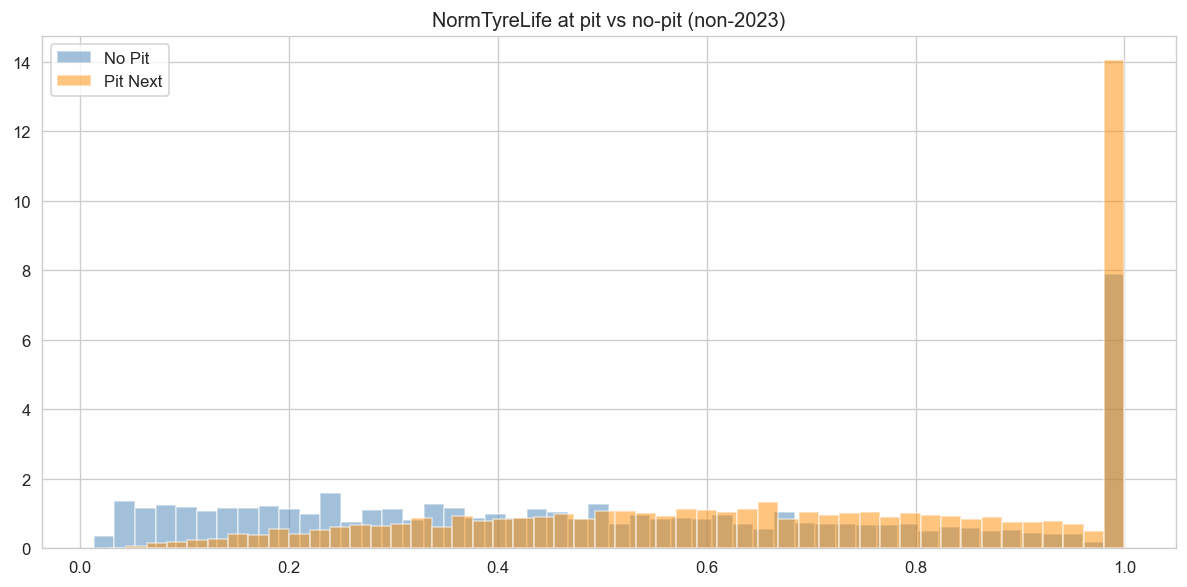

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
non2023_feat[non2023_feat[TARGET] == 0]['NormTyreLife'].hist(
    bins=50, alpha=0.5, density=True, label='No Pit', color='steelblue', ax=ax)
non2023_feat[non2023_feat[TARGET] == 1]['NormTyreLife'].hist(
    bins=50, alpha=0.5, density=True, label='Pit Next', color='darkorange', ax=ax)
ax.set_title('NormTyreLife at pit vs no-pit (non-2023)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. LR_x_TL interaction — the imminent pit signal

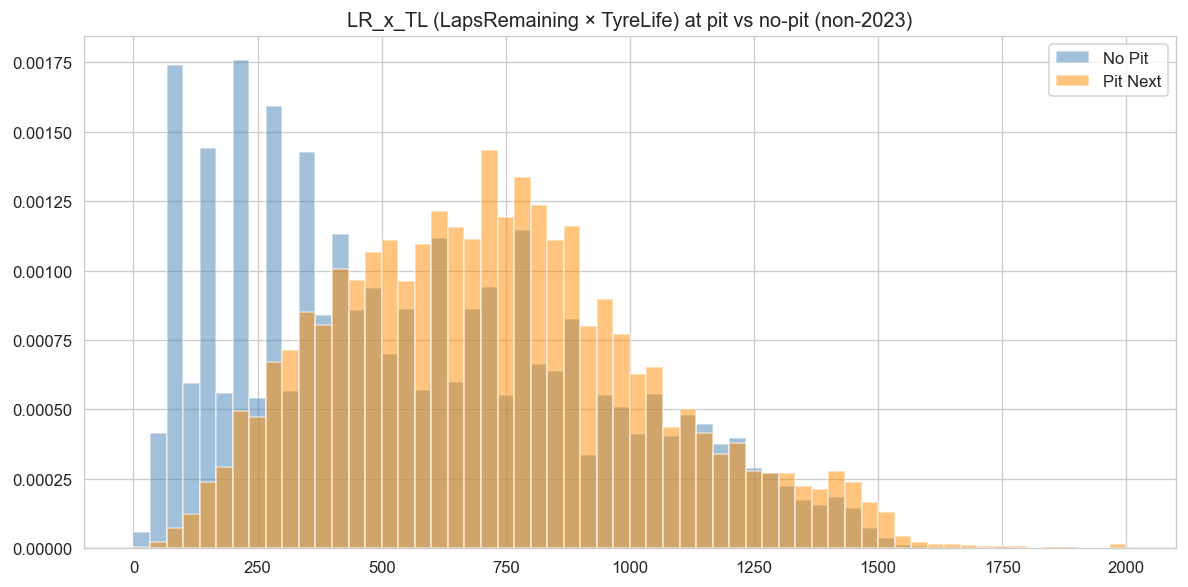

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
non2023_feat[non2023_feat[TARGET] == 0]['LR_x_TL'].clip(0, 2000).hist(
    bins=60, alpha=0.5, density=True, label='No Pit', color='steelblue', ax=ax)
non2023_feat[non2023_feat[TARGET] == 1]['LR_x_TL'].clip(0, 2000).hist(
    bins=60, alpha=0.5, density=True, label='Pit Next', color='darkorange', ax=ax)
ax.set_title('LR_x_TL (LapsRemaining × TyreLife) at pit vs no-pit (non-2023)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Lag feature coverage

In [8]:
lag_cols = ['LT_lag1', 'LT_lag2', 'LTD_lag1', 'TL_lag1', 'PitStop_lag1',
            'LT_roll3_mean', 'LT_roll3_std', 'LTD_roll3_mean']
lag_coverage = {c: (1 - train_feat[c].isnull().mean()) * 100 for c in lag_cols if c in train_feat.columns}
print('Lag feature coverage (% non-null):')
for k, v in lag_coverage.items():
    print(f'  {k}: {v:.1f}%')

Lag feature coverage (% non-null):
  LT_lag1: 93.4%
  LT_lag2: 87.4%
  LTD_lag1: 93.4%
  TL_lag1: 93.4%
  PitStop_lag1: 93.4%
  LT_roll3_mean: 93.4%
  LT_roll3_std: 87.4%
  LTD_roll3_mean: 93.4%


## 7. Save processed features for downstream notebooks

In [9]:
import pickle
from pathlib import Path

cache_dir = Path('..') / 'cache'
cache_dir.mkdir(exist_ok=True)

train_feat.to_pickle(cache_dir / 'train_feat.pkl')
test_feat.to_pickle(cache_dir / 'test_feat.pkl')
ext_feat.to_pickle(cache_dir / 'ext_feat.pkl')

print('Saved processed features to cache/')
print(f'  train_feat: {train_feat.shape}')
print(f'  test_feat:  {test_feat.shape}')
print(f'  ext_feat:   {ext_feat.shape}')
print(f'  feature_cols ({len(feature_cols)}): {feature_cols}')

Saved processed features to cache/
  train_feat: (439140, 37)
  test_feat:  (188165, 36)
  ext_feat:   (76929, 37)
  feature_cols (32): ['TyreLife', 'Stint', 'LapNumber', 'Position', 'RaceProgress', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'Position_Change', 'PitStop', 'LT_lag1', 'LT_lag2', 'LTD_lag1', 'TL_lag1', 'PitStop_lag1', 'LT_roll3_mean', 'LT_roll3_std', 'LTD_roll3_mean', 'NormTyreLife', 'Deg_per_lap', 'EstTotalLaps', 'LapsRemaining', 'LT_race_compound_mean', 'LT_vs_pace', 'TL_x_Stint', 'RP_x_TL', 'LR_x_TL', 'is_year2023', 'is_pretesting', 'is_real_driver', 'Compound_ord', 'Year']
